In [145]:
import numpy as np
import matplotlib.pyplot as plt

In [295]:
mu_1 = np.array([0, 0])
sigma_1 = np.array([[5, -0.9], [-0.9, 0.2]])

mu_2 = np.array([0, 0])
sigma_2 = np.array([[1, 0.7], [0.7, 1]])

In [296]:
xs = np.random.multivariate_normal(mu_1, sigma_1, size=1000)
ys = np.random.multivariate_normal(mu_2, sigma_2, size=1000)

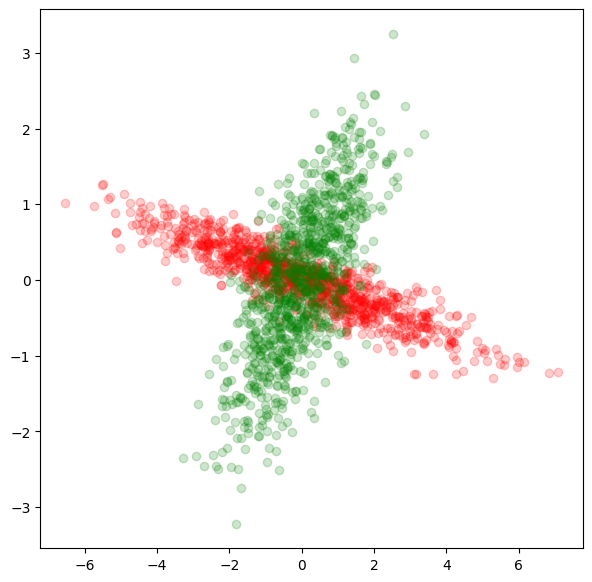

In [297]:
plt.figure(figsize=(7, 7))
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.2, c='red')
plt.scatter(ys[:, 0], ys[:, 1], alpha=0.2, c='green')

In [298]:
from scipy.linalg import fractional_matrix_power

In [299]:
def fractional_matrix_power_cov(mat: np.ndarray, alpha: float, eps=1e-8) -> np.ndarray:
    evals, evecs = np.linalg.eigh(mat)
    evals = np.clip(evals, a_min=0, a_max=None)
    evals = np.where(evals >= eps, evals ** alpha, 0.)
    return (evecs @ np.diag(evals) @ evecs.T)

In [300]:
mu_pos = np.mean(ys,axis=0)
sigma_pos = np.cov(ys.T)

mu_neg = np.mean(xs,axis=0)
sigma_neg = np.cov(xs.T)


sigma_neg_half = fractional_matrix_power_cov(sigma_neg, 0.5)
sigma_neg_minus_half = fractional_matrix_power_cov(sigma_neg, -0.5)
W = fractional_matrix_power_cov(sigma_neg_half @ sigma_pos @ sigma_neg_half, 0.5)
W = sigma_neg_minus_half @ W @ sigma_neg_minus_half

b = (- W @ mu_neg[..., None])[..., 0] + mu_pos


In [301]:
U, S, Vh = np.linalg.svd(W)

In [312]:
xs_sample = np.stack([np.linspace(0, 2, 100) ** 0.5, np.linspace(0, 2, 100)], axis=1)

In [313]:
xs_sample_transformed = (xs_sample @ U @ np.diag(S) @ Vh) + b[None, :]

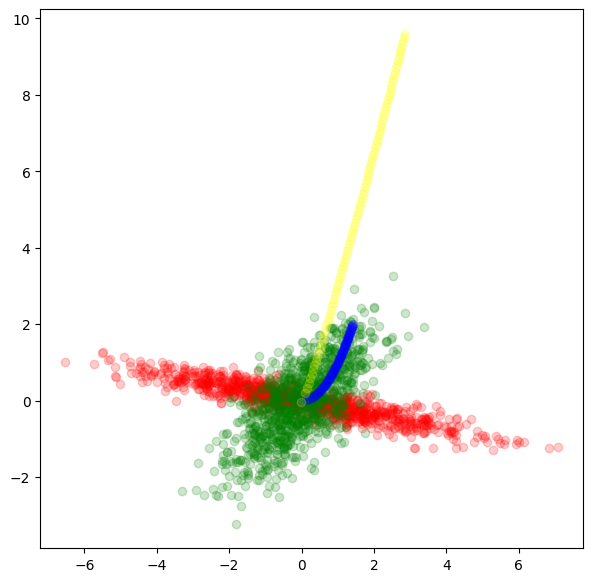

In [314]:
plt.figure(figsize=(7, 7))
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.2, c='red')
plt.scatter(ys[:, 0], ys[:, 1], alpha=0.2, c='green')

plt.scatter(xs_sample[:, 0], xs_sample[:, 1], alpha=0.2, c='blue')
plt.scatter(xs_sample_transformed[:, 0], xs_sample_transformed[:, 1], alpha=0.2, c='yellow')

In [294]:
np.linalg.eig(W)

EigResult(eigenvalues=array([0.34986799, 4.6084497 ]), eigenvectors=array([[-0.96966503, -0.24443759],
       [ 0.24443759, -0.96966503]]))

In [243]:
Vh

array([[ 0.24443759,  0.96966503],
       [ 0.96966503, -0.24443759]])

array([[1.00000000e+00, 1.43642871e-17],
       [1.43642871e-17, 1.00000000e+00]])